# Benchmark-Analyse: React 19 vs. Svelte 5
Hypothesen H1–H4 · Bachelorarbeit Jonas Öhler · 2026

## Abschnitt 0 — Konfiguration

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import os

# Pfad zur summary.csv — nach neuem Benchmark-Run hier anpassen
DATA_PATH   = '../benchmark/results/2026-06-08/summary.csv'
FIGURES_DIR = 'figures/2026-06-23'
os.makedirs(FIGURES_DIR, exist_ok=True)

COLOR_REACT  = '#5272A1'
COLOR_SVELTE = '#FFB200'
IQR_ALPHA    = 0.15
COLOR_WARN   = '#E87722'   # INP "Needs Improvement" Schwelle (200 ms)
COLOR_CRIT   = '#C0392B'   # INP "Poor" Schwelle (500 ms) / Frame-Budget

plt.rcParams.update({
    'font.family':      'Times New Roman',
    'font.serif':       ['Times New Roman'],
    'mathtext.fontset': 'stix',
    'font.size':        11,
    'axes.titlesize':   12,
    'axes.labelsize':   11,
    'legend.fontsize':  10,
    'figure.figsize':   (10, 6),
    'axes.grid':        True,
    'grid.alpha':       0.3,
    'lines.linewidth':  2.0,
    'lines.markersize': 7,
})

GRID_TICKS = [100, 400, 900, 1600, 4000, 10000]


## Abschnitt 1 — Daten laden & vorbereiten

In [2]:
df = pd.read_csv(DATA_PATH)
df['hz'] = (1000 / df['tickInterval']).round(0).astype(int)

react  = df[df['framework'] == 'react'].copy()
svelte = df[df['framework'] == 'svelte'].copy()

print(f"Szenarien geladen: {len(df)} Zeilen ({len(react)} React, {len(svelte)} Svelte)")
print(f"Grid-Größen : {sorted(df['gridSize'].unique())}")
print(f"Frequenzen  : {sorted(df['hz'].unique())} Hz")
df.head()


Szenarien geladen: 64 Zeilen (32 React, 32 Svelte)
Grid-Größen : [np.int64(100), np.int64(400), np.int64(900), np.int64(1600), np.int64(4000), np.int64(6000), np.int64(8000), np.int64(10000)]
Frequenzen  : [np.int64(10), np.int64(20), np.int64(30), np.int64(62)] Hz


,framework,gridSize,tickInterval,tickCount,inp,inputDelay,processingTime,presentationDelay,pooledEntries,scriptingMsPerTick_median,scriptingMsPerTick_iqr,renderingMsPerTick_median,renderingMsPerTick_iqr,longTaskCount_median,longTaskCount_iqr,longTaskMs_median,longTaskMs_iqr,heapDelta_median_bytes,hz
0,react,10000,100,100,NaN,NaN,NaN,NaN,NaN,11.163030,0.474010,13.185495,0.378640,0.0,1,0.0,53,4448314,10
1,react,10000,16,500,NaN,NaN,NaN,NaN,NaN,3.995584,0.126602,4.541365,0.078356,74.0,3,5206.0,188,4810224,62
2,react,10000,33,300,NaN,NaN,NaN,NaN,NaN,7.422675,0.290890,7.370150,0.063337,70.5,13,3923.0,777,4586992,30
3,react,10000,50,200,NaN,NaN,NaN,NaN,NaN,10.521382,1.020165,10.031852,0.321395,24.5,6,1421.5,273,4504358,20
4,react,100,100,100,352.0,0.3,0.0,351.7,4654.0,0.274030,0.009240,0.152415,0.004650,0.0,0,0.0,0,420444,10


## Abschnitt 2 — H2: Scripting-Overhead (CPU-Skalierung)
Referenzfrequenz: f = 10 Hz (tickInterval = 100 ms)

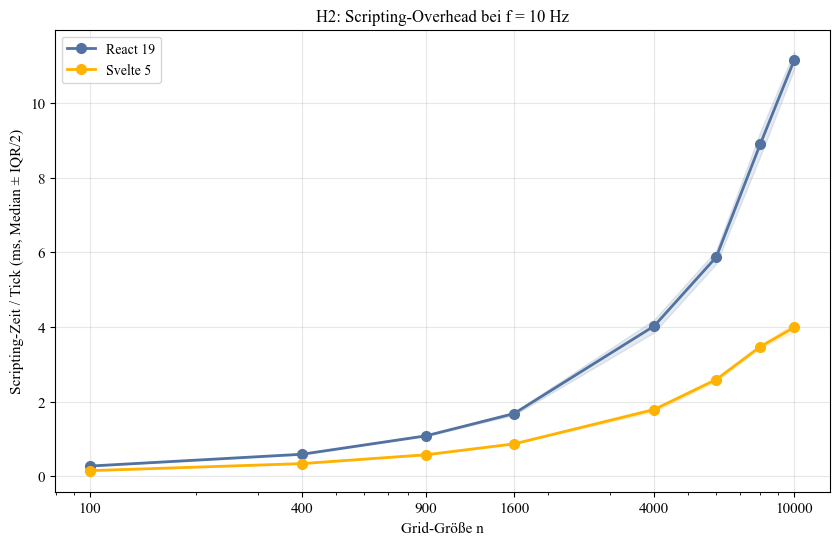

In [3]:
fig, ax = plt.subplots()

for data, color, label in [
    (react,  COLOR_REACT,  'React 19'),
    (svelte, COLOR_SVELTE, 'Svelte 5'),
]:
    sub = data[data['tickInterval'] == 100].sort_values('gridSize')
    med = sub['scriptingMsPerTick_median']
    iqr = sub['scriptingMsPerTick_iqr']
    ax.plot(sub['gridSize'], med, color=color, marker='o', label=label)
    ax.fill_between(sub['gridSize'],
                    np.maximum(0, med - iqr / 2),
                    med + iqr / 2,
                    color=color, alpha=IQR_ALPHA)

ax.set_xscale('log')
ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
ax.set_xticks(GRID_TICKS)
ax.set_xlabel('Grid-Größe n')
ax.set_ylabel('Scripting-Zeit / Tick (ms, Median ± IQR/2)')
ax.set_title('H2: Scripting-Overhead bei f = 10 Hz')
ax.legend()
fig_h2_scripting = fig
plt.show()


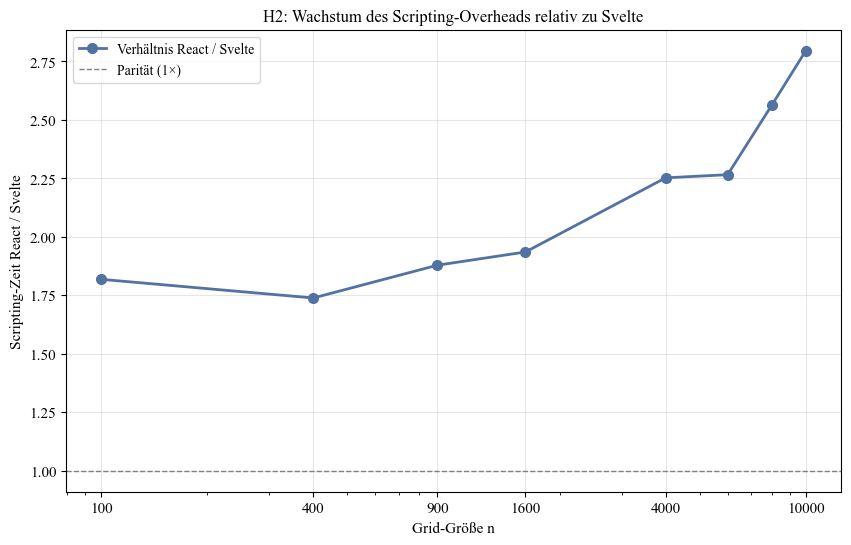

In [4]:
fig, ax = plt.subplots()

r = react[react['tickInterval'] == 100].sort_values('gridSize').set_index('gridSize')
s = svelte[svelte['tickInterval'] == 100].sort_values('gridSize').set_index('gridSize')
ratio = r['scriptingMsPerTick_median'] / s['scriptingMsPerTick_median']

ax.plot(ratio.index, ratio.values, color=COLOR_REACT, marker='o', label='Verhältnis React / Svelte')
ax.axhline(y=1, color='gray', linestyle='--', linewidth=1, label='Parität (1×)')
ax.set_xscale('log')
ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
ax.set_xticks(GRID_TICKS)
ax.set_xlabel('Grid-Größe n')
ax.set_ylabel('Scripting-Zeit React / Svelte')
ax.set_title('H2: Wachstum des Scripting-Overheads relativ zu Svelte')
ax.legend()
fig_h2_ratio = fig
plt.show()


## Abschnitt 3 — H3: Speichereffizienz
JS-Heap-Delta nach erzwungener GC, Referenzfrequenz: f = 10 Hz

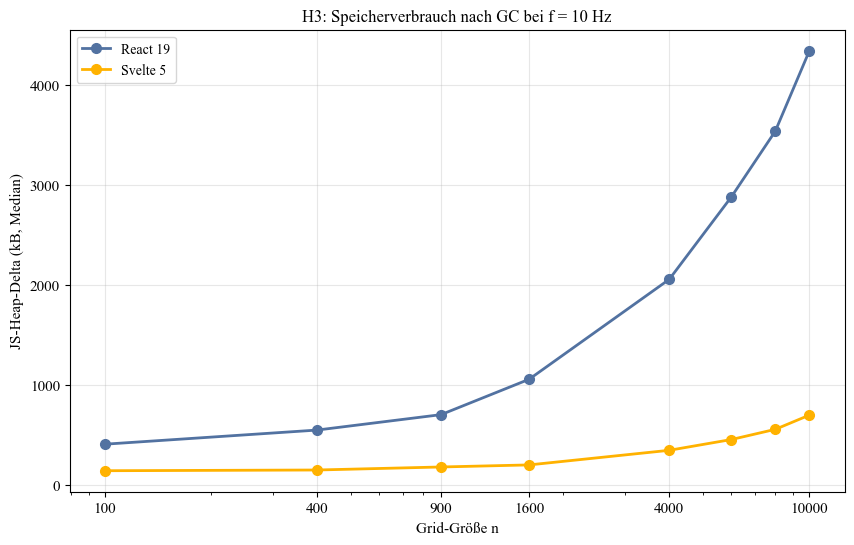

In [5]:
fig, ax = plt.subplots()

for data, color, label in [
    (react,  COLOR_REACT,  'React 19'),
    (svelte, COLOR_SVELTE, 'Svelte 5'),
]:
    sub = data[data['tickInterval'] == 100].sort_values('gridSize')
    ax.plot(sub['gridSize'], sub['heapDelta_median_bytes'] / 1024,
            color=color, marker='o', label=label)

ax.set_xscale('log')
ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
ax.set_xticks(GRID_TICKS)
ax.set_xlabel('Grid-Größe n')
ax.set_ylabel('JS-Heap-Delta (kB, Median)')
ax.set_title('H3: Speicherverbrauch nach GC bei f = 10 Hz')
ax.legend()
fig_h3_memory = fig
plt.show()


In [ ]:
fig, ax = plt.subplots()

r = react[react['tickInterval'] == 100].sort_values('gridSize').set_index('gridSize')
s = svelte[svelte['tickInterval'] == 100].sort_values('gridSize').set_index('gridSize')
mem_ratio = r['heapDelta_median_bytes'] / s['heapDelta_median_bytes']

ax.plot(mem_ratio.index, mem_ratio.values, color=COLOR_REACT, marker='o',
        label='Verhältnis React / Svelte')
ax.axhline(y=1, color='gray', linestyle='--', linewidth=1, label='Parität (1×)')
ax.set_xscale('log')
ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
ax.set_xticks(GRID_TICKS)
ax.set_xlabel('Grid-Größe n')
ax.set_ylabel('Heap-Delta React / Svelte')
ax.set_title('H3: React-Speicher-Overhead relativ zu Svelte (3× bis 6,4×)')
ax.legend()
fig_h3_ratio = fig
plt.show()

## Abschnitt 4 — H1: Interaktionslatenz (INP)
Vergleich bei f = 63 Hz (tickInterval 16 ms) und f = 10 Hz (tickInterval 100 ms)

In [ ]:
from matplotlib.lines import Line2D

fig, ax = plt.subplots()

FREQ_STYLES = [(16, '-'), (100, '--')]

for data, color in [(react, COLOR_REACT), (svelte, COLOR_SVELTE)]:
    for interval, ls in FREQ_STYLES:
        sub = data[data['tickInterval'] == interval].sort_values('gridSize')
        ax.plot(sub['gridSize'], sub['inp'], color=color, linestyle=ls, marker='o')

# INP "Needs Improvement" threshold — all data is in the "Good" range (< 200 ms)
ax.axhline(y=200, color=COLOR_WARN, linestyle=':', linewidth=1.5)
ax.set_ylim(0, 230)

legend_handles = [
    Line2D([0],[0], color=COLOR_REACT,  linewidth=2,   label='React 19'),
    Line2D([0],[0], color=COLOR_SVELTE, linewidth=2,   label='Svelte 5'),
    Line2D([0],[0], color='gray', linewidth=2, linestyle='-',  label='≈ 62 Hz (f = 16 ms)'),
    Line2D([0],[0], color='gray', linewidth=2, linestyle='--', label='10 Hz (f = 100 ms)'),
    Line2D([0],[0], color=COLOR_WARN, linewidth=1.5, linestyle=':', label='"Needs Improvement" (200 ms)'),
]
ax.legend(handles=legend_handles, fontsize=9, ncol=2, handlelength=3, loc='center left')

ax.set_xscale('log')
ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
ax.set_xticks(GRID_TICKS)
ax.set_xlabel('Grid-Größe n')
ax.set_ylabel('INP (ms)')
ax.set_title('H1: Interaktionslatenz (INP) bei ≈ 62 Hz und 10 Hz')
fig_h1_inp = fig
plt.show()

## Abschnitt 5 — H4: Tipping Point
Frame-Budget-Auslastung und Long Tasks als Operationalisierung des Tipping Points

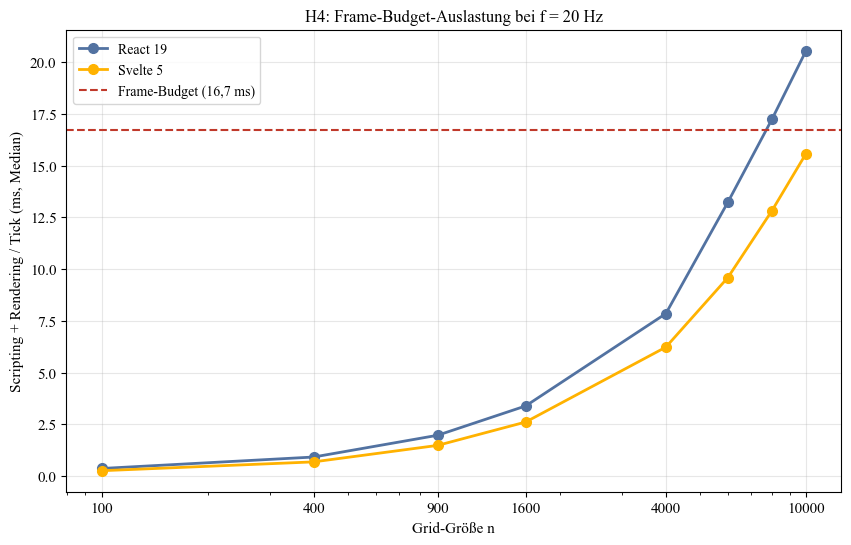

In [8]:
fig, ax = plt.subplots()

for data, color, label in [
    (react,  COLOR_REACT,  'React 19'),
    (svelte, COLOR_SVELTE, 'Svelte 5'),
]:
    sub = data[data['tickInterval'] == 50].sort_values('gridSize')
    total = sub['scriptingMsPerTick_median'] + sub['renderingMsPerTick_median']
    ax.plot(sub['gridSize'], total, color=color, marker='o', label=label)

ax.axhline(y=16.7, color=COLOR_CRIT, linestyle='--', linewidth=1.5,
           label='Frame-Budget (16,7 ms)')
ax.set_xscale('log')
ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
ax.set_xticks(GRID_TICKS)
ax.set_xlabel('Grid-Größe n')
ax.set_ylabel('Scripting + Rendering / Tick (ms, Median)')
ax.set_title('H4: Frame-Budget-Auslastung bei f = 20 Hz')
ax.legend()
fig_h4_frame = fig
plt.show()


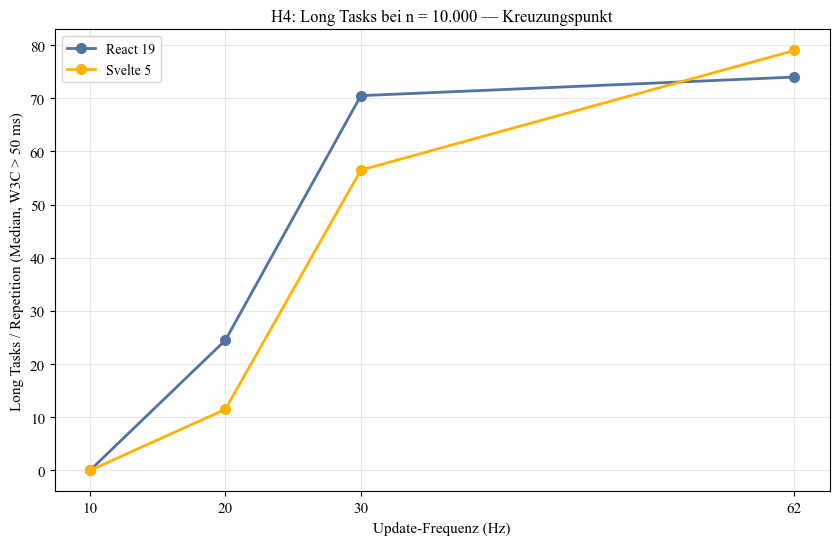

In [9]:
if 'longTaskCount_median' in df.columns:
    fig, ax = plt.subplots()

    n10k = df[df['gridSize'] == 10000].sort_values('hz')
    for fw, color, label in [
        ('react',  COLOR_REACT,  'React 19'),
        ('svelte', COLOR_SVELTE, 'Svelte 5'),
    ]:
        sub = n10k[n10k['framework'] == fw]
        ax.plot(sub['hz'], sub['longTaskCount_median'],
                color=color, marker='o', label=label)

    ax.set_xlabel('Update-Frequenz (Hz)')
    ax.set_ylabel('Long Tasks / Repetition (Median, W3C > 50 ms)')
    ax.set_title('H4: Long Tasks bei n = 10.000 — Kreuzungspunkt')
    ax.legend()
    ax.set_xticks(sorted(n10k['hz'].unique()))
    fig_h4_longtasks = fig
    plt.show()
else:
    print("Hinweis: longTaskCount_median fehlt in den Daten.")
    print("Benchmark mit Long-Task-Messung ausführen und bench:summarize neu starten.")
    fig_h4_longtasks = None


## Abschnitt 6 — Export
Alle Abbildungen als PDF nach `figures/` — direkt in LaTeX einbindbar.

In [10]:
for _name in ['fig_h2_scripting','fig_h2_ratio','fig_h3_memory',
              'fig_h3_ratio','fig_h1_inp','fig_h4_frame','fig_h4_longtasks']:
    if _name not in dir():
        globals()[_name] = None

EXPORT = {
    'h2_scripting.pdf':       fig_h2_scripting,
    'h2_scripting_ratio.pdf': fig_h2_ratio,
    'h3_memory.pdf':          fig_h3_memory,
    'h3_memory_ratio.pdf':    fig_h3_ratio,
    'h1_inp.pdf':             fig_h1_inp,
    'h4_frame_budget.pdf':    fig_h4_frame,
    'h4_long_tasks.pdf':      fig_h4_longtasks,
}

for filename, fig in EXPORT.items():
    if fig is not None:
        path = os.path.join(FIGURES_DIR, filename)
        fig.savefig(path, dpi=300, bbox_inches='tight')
        print(f"Gespeichert : {path}")
    else:
        print(f"Übersprungen: {filename} (keine Daten)")


Gespeichert : figures\h2_scripting.pdf
Gespeichert : figures\h2_scripting_ratio.pdf


Gespeichert : figures\h3_memory.pdf
Gespeichert : figures\h3_memory_ratio.pdf


Gespeichert : figures\h1_inp.pdf
Gespeichert : figures\h4_frame_budget.pdf
Gespeichert : figures\h4_long_tasks.pdf
